In [9]:
import matplotlib.pyplot as plt
import torch

from score.score import Score2d
from score.distributions import standard_gaussian_2d, symmetric_gaussian_mixture_2d 

In [2]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 2))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
score = Score2d(model, optimizer, symmetric_gaussian_mixture_2d())

In [3]:
loss, grad_norm = score.learn(
	n_samples_per_iter = 1000,
	n_iters = 500,
	debug = True
)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:52<00:00, 95.77it/s] 


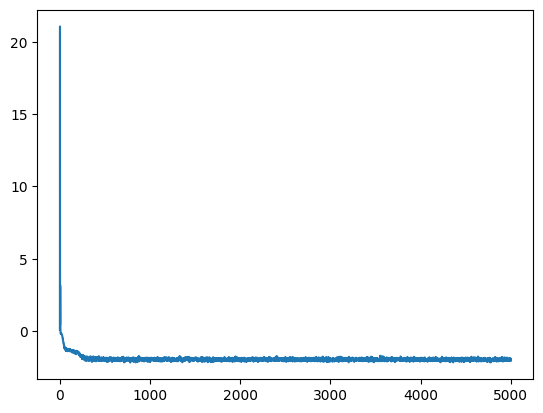

In [4]:
plt.plot(loss)

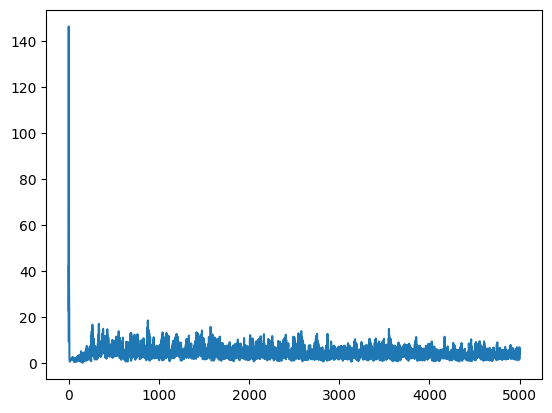

In [5]:
plt.plot(grad_norm)

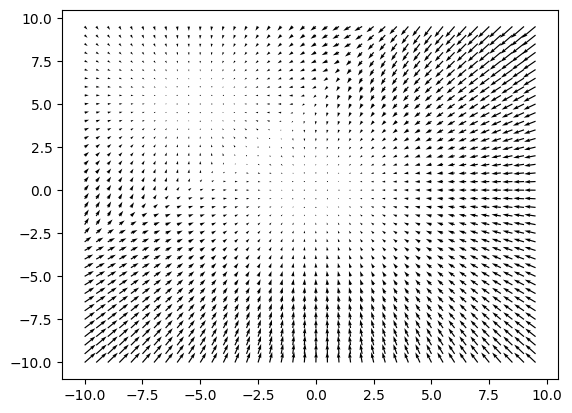

In [8]:
g, s = score.score_approx(-10, 10, -10, 10, 0.5)
g, s = g.numpy().T, s.numpy().T
plt.quiver(g[0], g[1], s[0], s[1])

In [10]:
init_samples = standard_gaussian_2d().sample((1000, ))
samples = score.sample_langevin(
	init_samples = init_samples,
	n_steps = 1000,
	epsilon = 0.1
)

100%|██████████| 1000/1000 [00:00<00:00, 1768.19it/s]


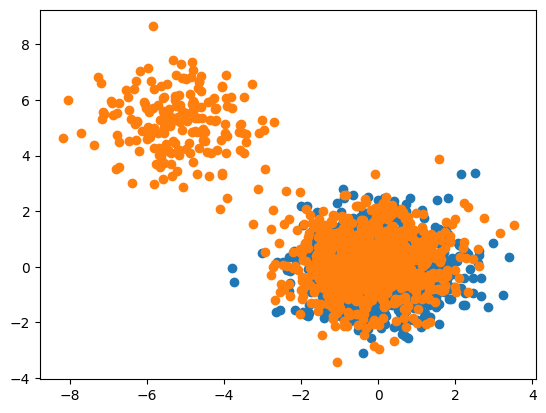

In [11]:
init_samples = init_samples.numpy().T
samples = samples.numpy().T
plt.scatter(init_samples[0], init_samples[1])
plt.scatter(samples[0], samples[1])